In [6]:
from toolbox.periodic import PeriodicTissue
from toolbox.cellDriver import CellDriver
import os
import numpy as np



#prepare_dir
test_dir = "tests/test_cell_driver/"
os.system("rm -rf {}".format(test_dir))
os.system("cp -r init/init_homogeneous_6/000/ {}".format(test_dir))

tissue = PeriodicTissue.from_config(test_dir, "minimized.txt")
driver = CellDriver.periodic_tissue(tissue)
driver.set_central_target_cell()
driver.set_direction(np.array([1.0, 0.0, 0.0]))
driver.set_target_cell_neighbors_s0()
driver.set_cpp_executable_dir("/home/shabeeb/Projects/tvm-fire/build/")
driver.minimize_config()
for cellID,cell in driver._config.cells_.items():
    cell.vtk_scalar_ = cell.s0_
    for polygonID,polygon in cell.polygons_.items():
        polygon.vtk_scalar_ = cell.vtk_scalar_
driver._config.write_periodic_vtk("result.vtk",use_scalar=True)


Initialization start ...


Initial F_rms: 0.072748
Proceeding with overdamping and FIRE minimization.

Starting overdamped motion...
Real time elapsed: Rte

Time        Rte         Volume      I->H        H->I        E_volume    E_interface Energy      F_rms       
0.00        0.001       216.000     0           0           0.102293    31.003981   31.106274   0.072748    
100.00      22.541      216.000     0           0           0.152143    30.585526   30.737669   0.020894    

   Zero reconnections since the previous log dump.
   Terminating overdamped motion and proceeding to FIRE minimization.

Starting FIRE minimization...
Real time elapsed: Rte

Iter     Rte   Volume   I->H     H->I     E_V      E_S      Energy      Power       F_rms       
0        0.0   216.0    0        0        0.2      30.6     30.7        1.7         2.0873458e-02
1000     2.6   216.0    0        0        0.2      30.4     30.5        0.0         3.0374970e-06
   FIRE minimization terminated successfully a

AttributeError: 'list' object has no attribute 'items'

In [28]:
import pandas as pd

test = 69
td = {1:0.5,2:5.3}
td_list = list(td.items())
print(td_list)

df = pd.DataFrame(list(td.items()),columns=["a","b"])
df["c"] = test
print(df)
td_loaded = dict(zip(df["a"].to_numpy(),df["b"].to_numpy()))
print(td_loaded)

[(1, 0.5), (2, 5.3)]
   a    b   c
0  1  0.5  69
1  2  5.3  69
{np.int64(1): np.float64(0.5), np.int64(2): np.float64(5.3)}


In [1]:
#single pattern
# 
import os
import numpy as np

#prepare_dir
test_dir = "tests/two_cells_error_cost/"
stresses = np.loadtxt("init/init_homogeneous_4/stresses.txt")
os.system("rm -rf {}".format(test_dir))
os.system("cp -r init/init_homogeneous_4/000 {}".format(test_dir))
os.system("echo 2 > {}n_cells".format(test_dir))
os.system("echo {} > {}target".format(np.mean(stresses), test_dir))
os.system("echo 1e-7 > {}tolerance".format(test_dir))
os.system("echo 100 > {}max_iters".format(test_dir))

0

In [ ]:
#test multiple patterns
from scripts.multiple_patterns import multiple_patterns
import os
import numpy as np

#prepare_dir
test_dir = "tests/test_multiple_patterns_one_cell/"
stresses = np.loadtxt("init/init_homogeneous_4/stresses.txt")
os.system("rm -rf {}".format(test_dir))
os.system("cp -r init/init_homogeneous_4/000 {}".format(test_dir))
os.system("echo 1 > {}n_cells_A".format(test_dir))
os.system("echo 2 > {}n_cells_B".format(test_dir))
os.system("echo {} > {}target".format(np.mean(stresses), test_dir))
os.system("echo 1e-6 > {}tolerance".format(test_dir))
os.system("echo 100 > {}max_iters".format(test_dir))




0

In [24]:
from scripts.data_processing import download_all
download_all("2_cells_mean_l_4/")
download_all("2_cells_mean_l_5/")
download_all("2_cells_mean_l_6/")
download_all("3_cells_mean_l_6/")
download_all("4_cells_mean_l_4/")
download_all("4_cells_mean_l_5/")
download_all("4_cells_mean_l_6/")
download_all("5_cells_mean_l_6/")
download_all("6_cells_mean_l_6/")

scp: /home/mameen/2_cells_mean_l_4/006/errors.txt: No such file or directory
scp: /home/mameen/2_cells_mean_l_4/006/q_values.txt: No such file or directory
scp: /home/mameen/2_cells_mean_l_4/022/errors.txt: No such file or directory
scp: /home/mameen/2_cells_mean_l_4/025/errors.txt: No such file or directory
scp: /home/mameen/2_cells_mean_l_4/028/errors.txt: No such file or directory
scp: /home/mameen/2_cells_mean_l_4/030/errors.txt: No such file or directory
scp: /home/mameen/2_cells_mean_l_4/032/errors.txt: No such file or directory
scp: /home/mameen/2_cells_mean_l_4/042/errors.txt: No such file or directory
scp: /home/mameen/2_cells_mean_l_4/043/errors.txt: No such file or directory
scp: /home/mameen/2_cells_mean_l_4/043/q_values.txt: No such file or directory
scp: /home/mameen/2_cells_mean_l_4/044/errors.txt: No such file or directory
scp: /home/mameen/2_cells_mean_l_4/051/errors.txt: No such file or directory
scp: /home/mameen/2_cells_mean_l_4/070/errors.txt: No such file or direc

In [11]:
import numpy as np
import pandas as pd
dir = "tests/test_multiple_patterns_one_cell/"
distances = pd.read_csv("{}info".format(dir))["Distance"].to_numpy()
print(distances[-10:])
print(np.allclose(distances[-10:], distances[-1], atol=0.01))
print("Parameter space distance not changing. Stopping training.")

[4.18950071 4.19114435 4.19657825 4.19807347 4.2034915  4.20484795
 4.21024447 4.21147664 4.21684562 4.2179569 ]
False
Parameter space distance not changing. Stopping training.


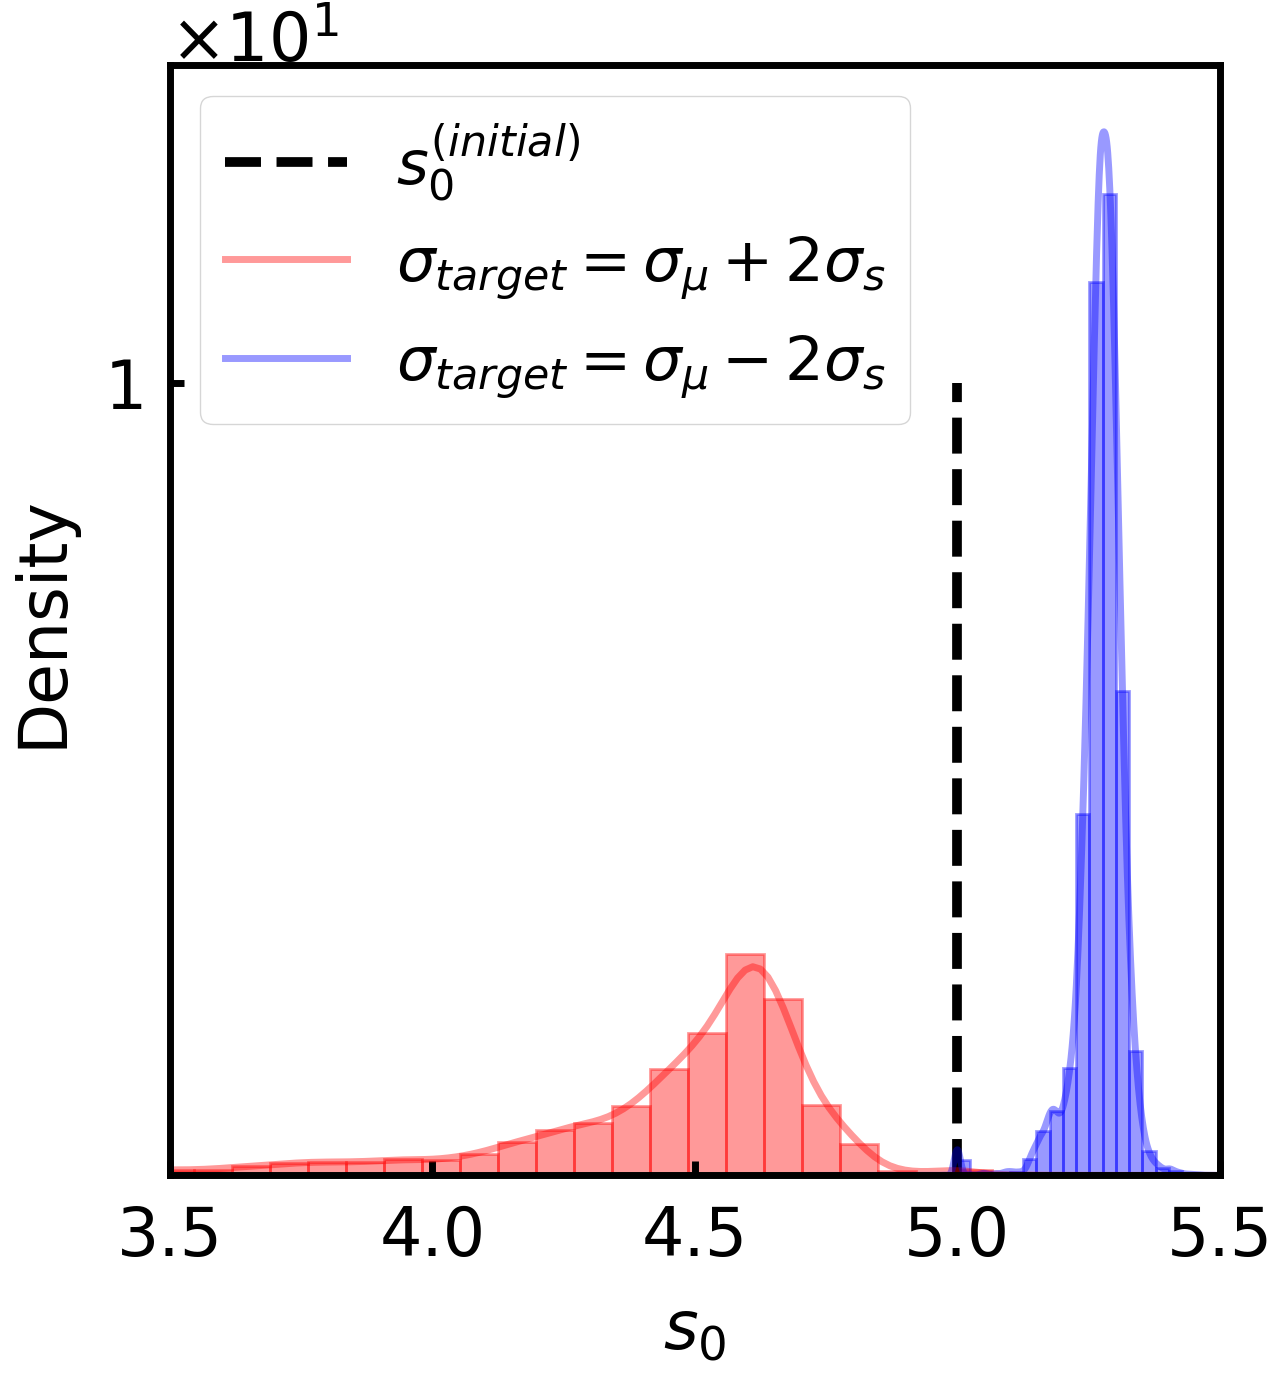

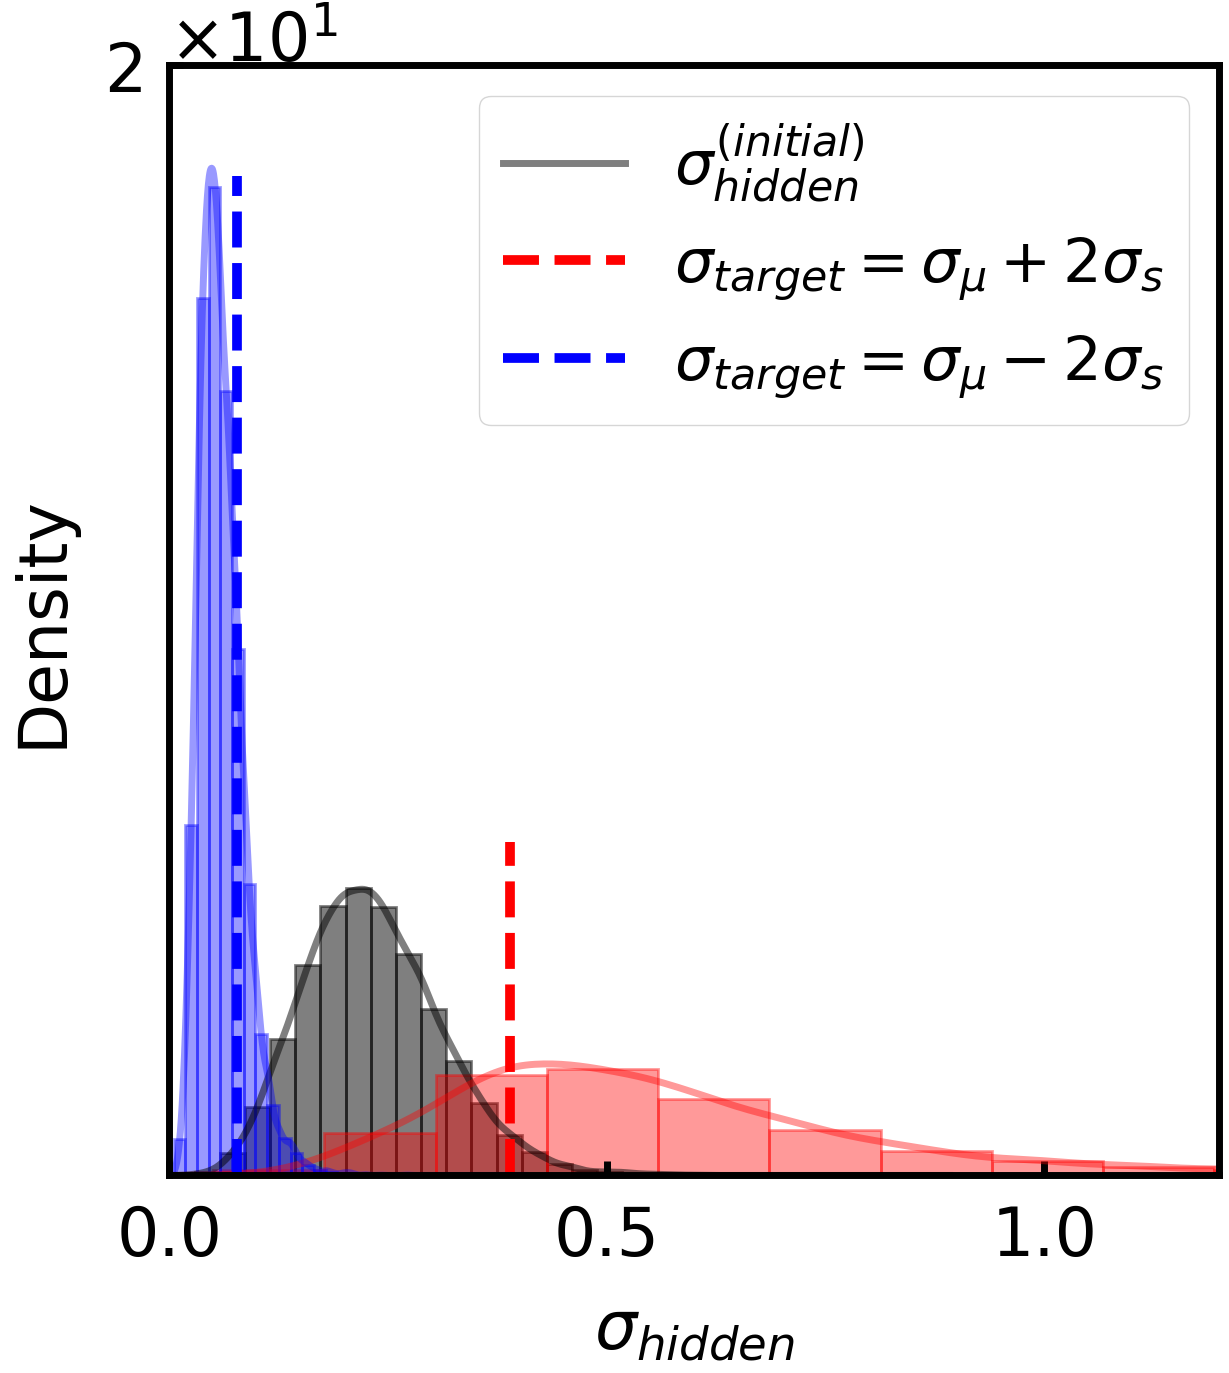

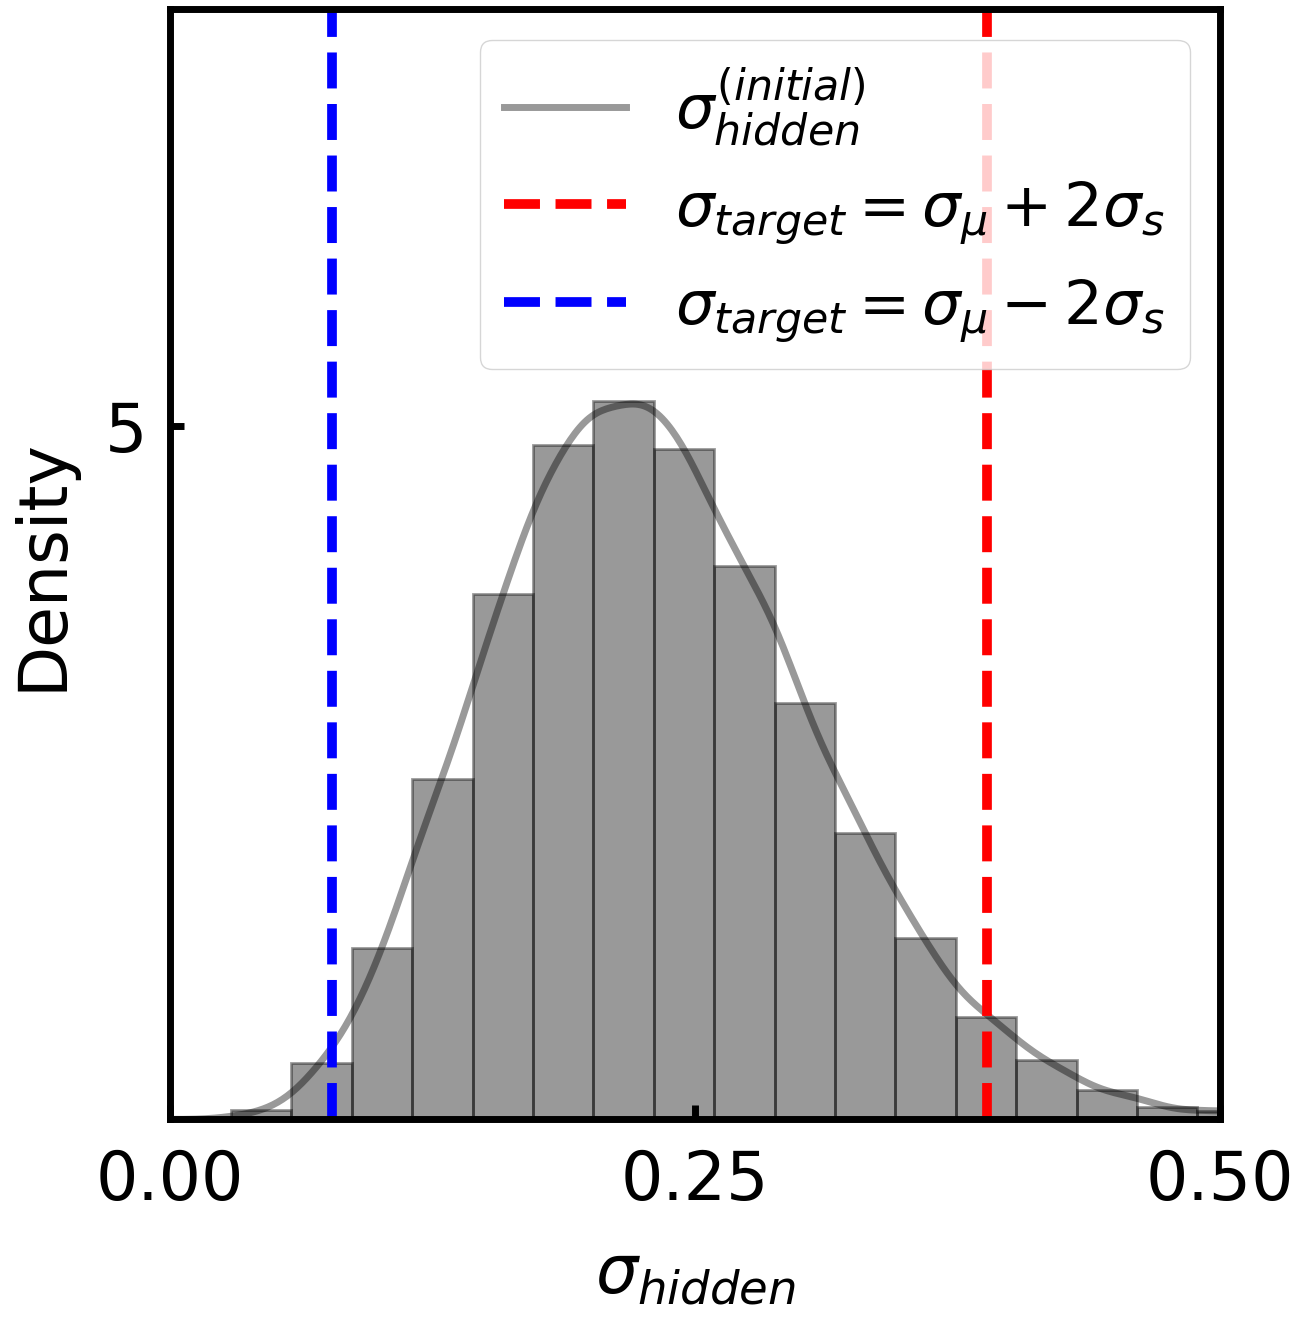

In [1]:
from scripts.plotgenerator import *
import numpy as np
inc_dir="data_6/1_cell_increase_2_sigma/"
dec_dir="data_6/1_cell_decrease_2_sigma/"

single_cell_combined_s0_histogram(inc_dir=inc_dir, dec_dir=dec_dir)
single_cell_combined_stress_histogram(init_stresses = np.loadtxt("data_6/stresses.txt") , inc_dir=inc_dir, dec_dir=dec_dir)
single_cell_initial_stress_histogram(array = np.loadtxt("data_6/stresses.txt"))

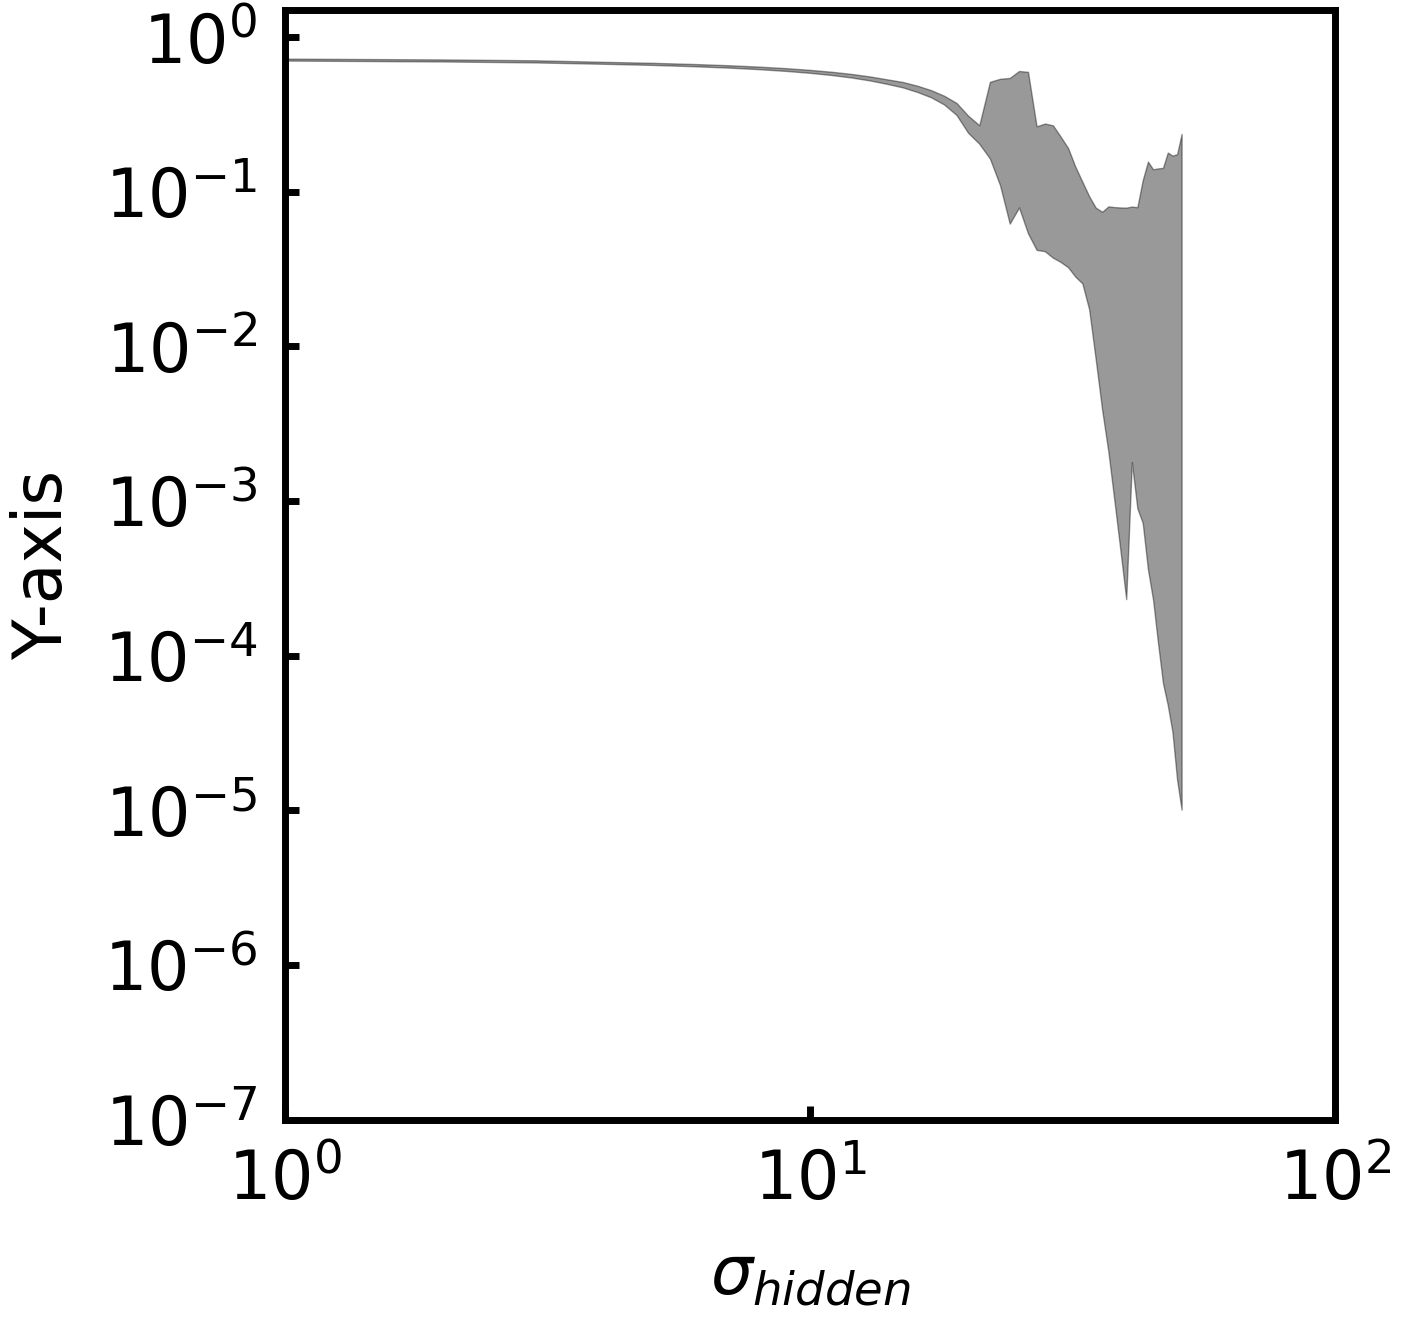

In [16]:
import numpy as np
import os
import pandas as pd
import scipy.stats as stats
from toolbox import manuscriptPlots

def mean_sem_by_index_fast(arrs_dict, min_count=3, ddof=1, drop_insufficient=True):
    wide = pd.DataFrame({k: pd.Series(v) for k, v in arrs_dict.items()})
    counts = wide.count(axis=1)
    means  = wide.mean(axis=1)
    stds   = wide.std(axis=1, ddof=ddof)              # ignores NaNs
    sems   = stds / np.sqrt(counts)
    need   = max(min_count, ddof + 1)
    sems[counts < need] = np.nan
    out = pd.DataFrame({"mean": means, "sem": sems})
    if drop_insufficient:
        out = out[counts >= need]
    out.index.name = "n"
    return out
source_to_target_decrease = {}
for i in range(10):
    dir = "data/1_cell_decrease_2_sigma/{:03d}/".format(i)
    if os.path.isfile(dir+"errors.txt"):
        source_to_target_decrease[dir] = np.loadtxt(dir+"errors.txt")
df_decrease = mean_sem_by_index_fast(source_to_target_decrease)

plotter = manuscriptPlots.plot()
plotter.set_ylim(1e-7,1.5)
plotter.set_xlim(1,100)
plotter.set_xticks([20*i for i in range(150)])
plotter.set_yticks([5*i for i in range(1,100)])
plotter.set_xlabel(r"$\sigma_{hidden}$")
plotter.set_yScaled()
plotter.initialize_figure()
x_array = [i+1 for i in range(len(df_decrease["mean"].to_numpy()))]
plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
plotter.ax.set_yscale("log")

# mean = np.mean(array)
# std = np.std(array)
# plotter.ax.vlines(mean+2*std, ymin = 0, ymax = 4,linestyles= "--", color = "red",alpha = 1,label = r"$\sigma_{target} = \sigma_\mu+2\sigma_s$")
# plotter.ax.vlines(mean-2*std, ymin = 0, ymax = 4,linestyles= "--", color = "blue",alpha = 1,label = r"$\sigma_{target} = \sigma_\mu-2\sigma_s$")
# plotter.ax.legend(loc='upper right')
# plotter.save_fig("graphs/{}".format(filename))


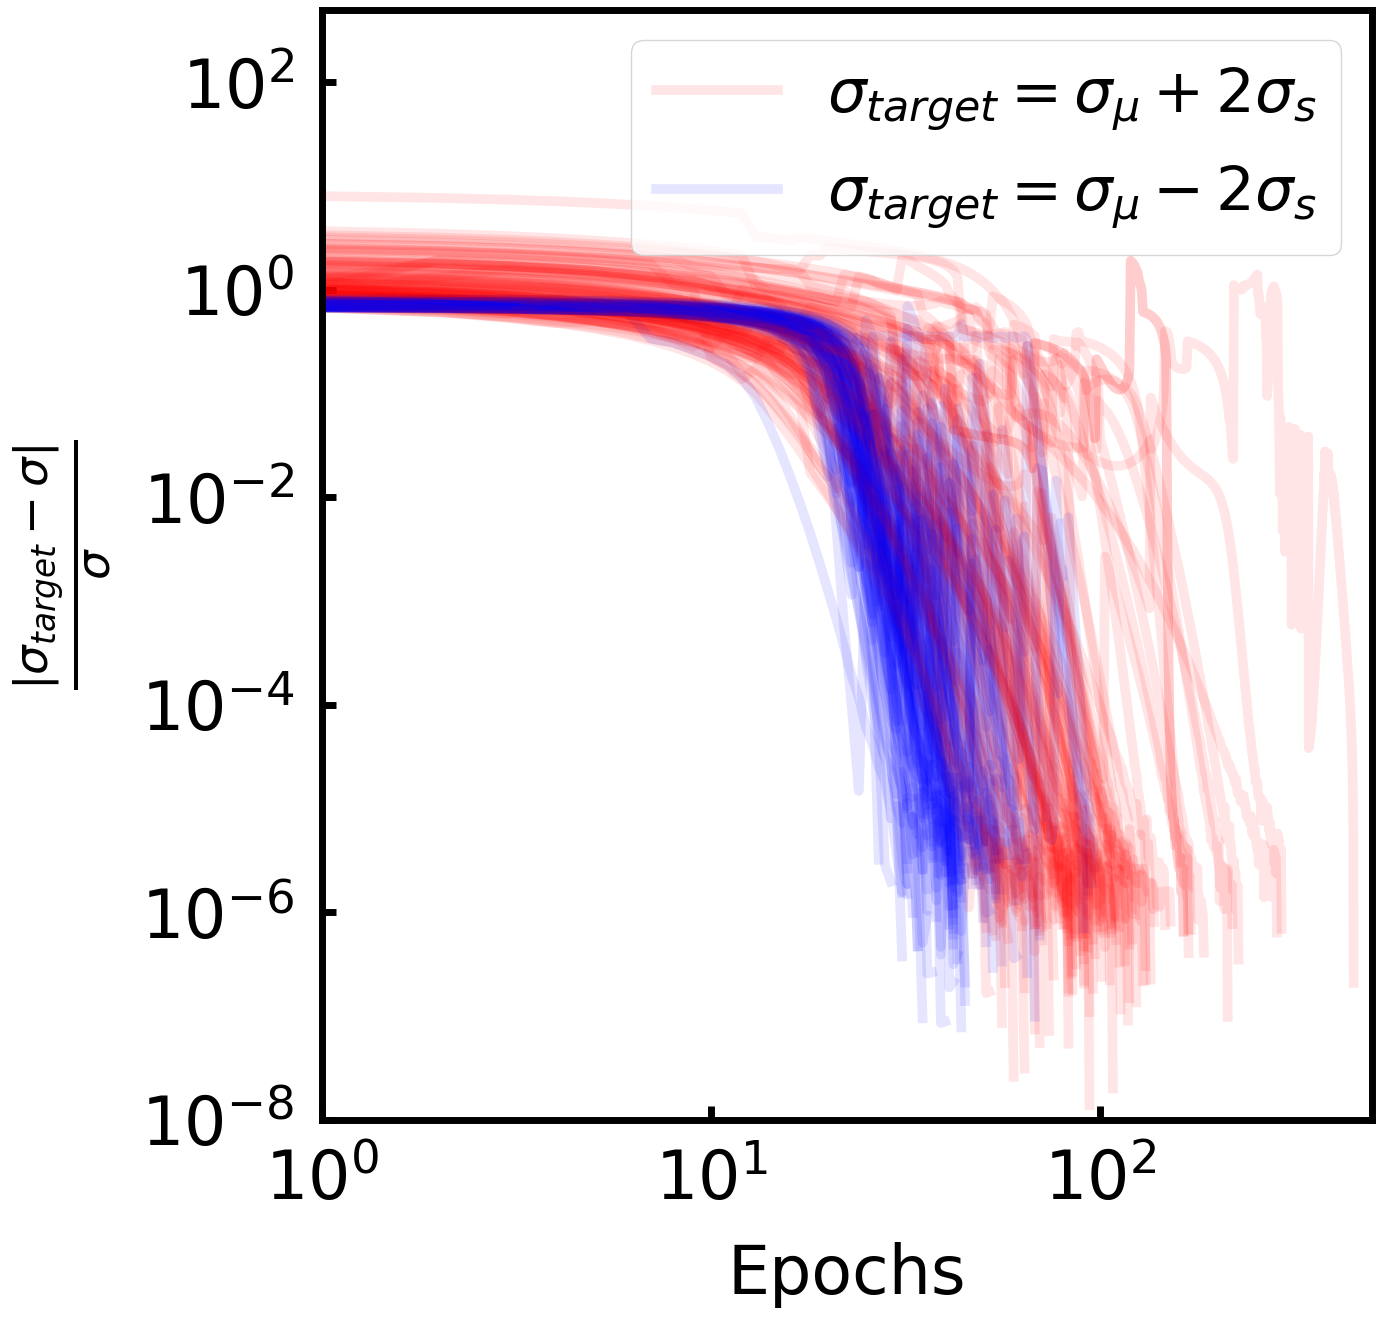

In [4]:
## single cell, errors for all runs
from toolbox import manuscriptPlots
import os
import numpy as np
plotter = manuscriptPlots.plot()
plotter.set_ylim(1e-8,5e2)
plotter.set_xlim(1,500)
plotter.set_xticks([20*i for i in range(150)])
plotter.set_yticks([5*i for i in range(1,100)])
plotter.set_xlabel("Epochs")
plotter.set_ylabel(r"$\frac{|\sigma_{target}-\sigma|}{\sigma}$")

plotter.set_yScaled()
plotter.initialize_figure()
for i in range(100):
    
    dir = "data/1_cell_increase_2_sigma/{:03d}/".format(i)
    if not os.path.isfile(dir+"errors.txt"):
        continue
    errors = np.loadtxt(dir+"errors.txt")
    if errors[-1]>5e-6:
        continue
    x_array = [i+1 for i in range(len(errors))]
    plotter.plot_xy(x_array, errors, color ="red", alpha = 0.1,label = "_none")
    if i==99:
        plotter.plot_xy(x_array, errors, color ="red", alpha = 0.1, label = r"$\sigma_{target}=\sigma_\mu + 2\sigma_s$")


    dir = "data/1_cell_decrease_2_sigma/{:03d}/".format(i)
    if not os.path.isfile(dir+"errors.txt"):
        continue
    errors = np.loadtxt(dir+"errors.txt")
    if errors[-1]>5e-6:
        continue
    x_array = [i+1 for i in range(len(errors))]
    plotter.plot_xy(x_array, errors, color ="blue", alpha = 0.1,label = "_none")
    if i==99:
        plotter.plot_xy(x_array, errors, color ="blue", alpha = 0.1, label = r"$\sigma_{target}=\sigma_\mu - 2\sigma_s$")
    

# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
plotter.ax.set_yscale("log")
plotter.ax.legend(loc='upper right')
plotter.save_fig("graphs/single_cell_errors.jpg")


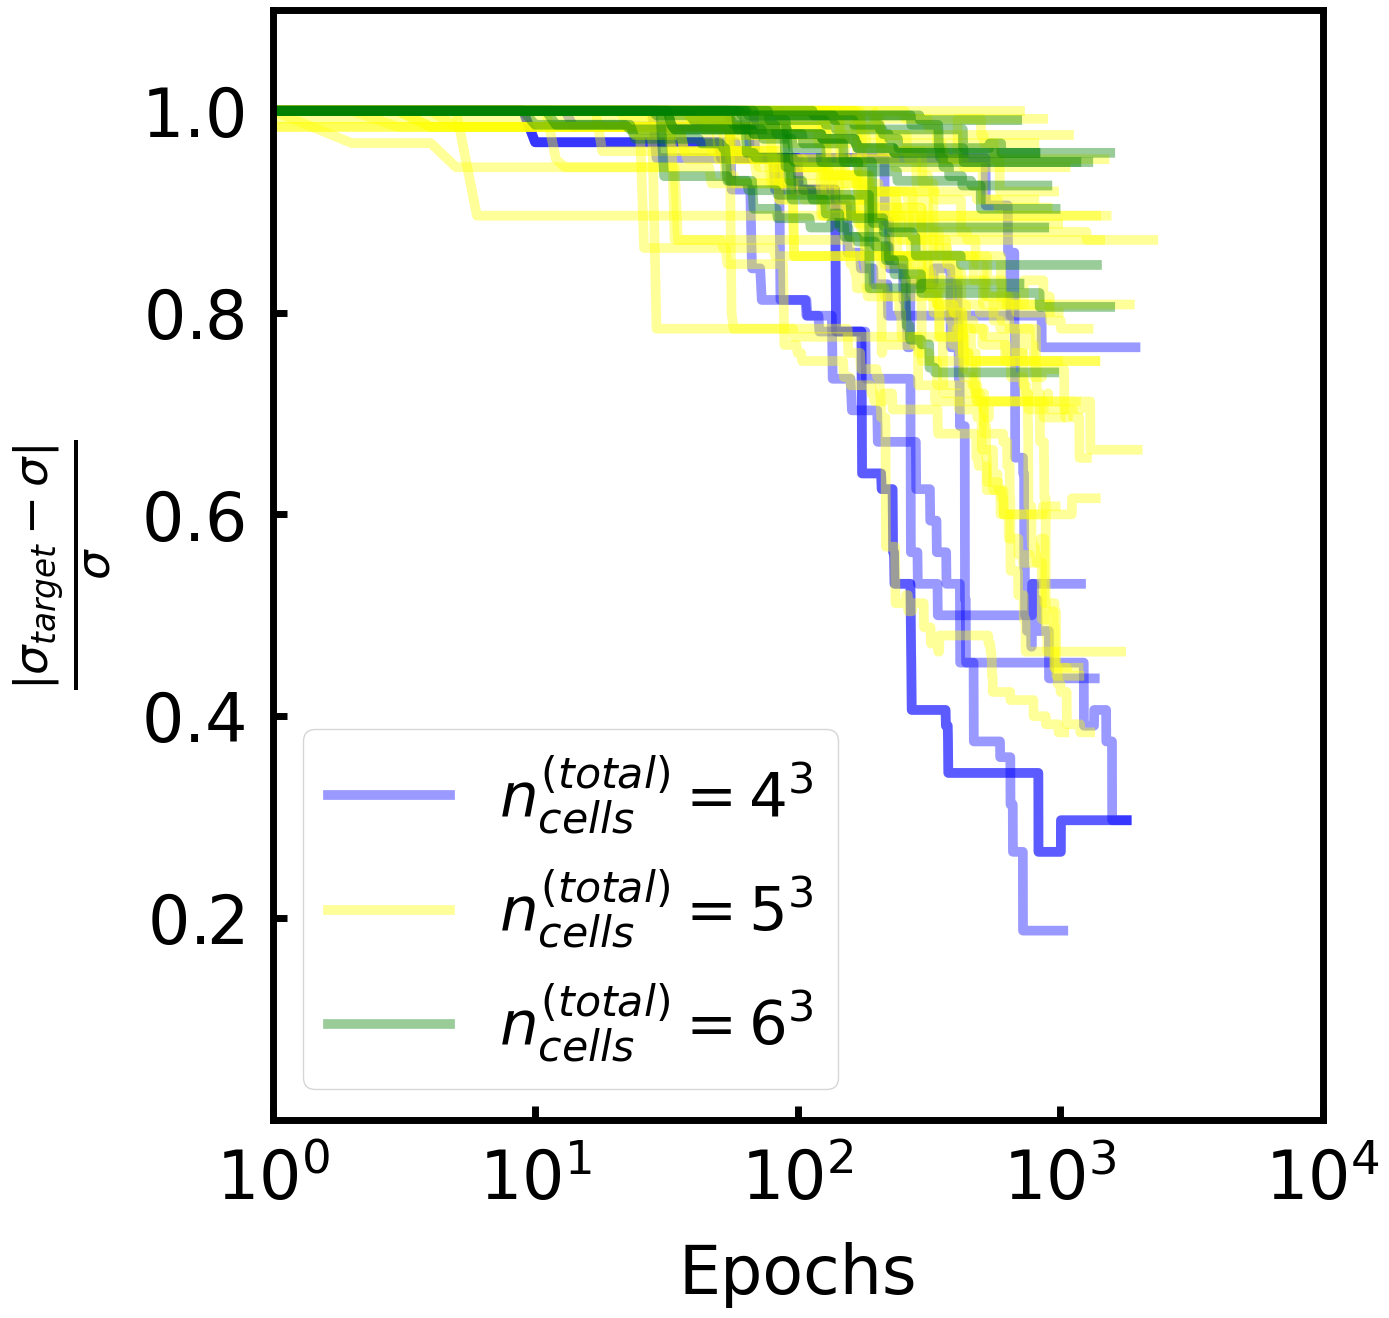

In [ ]:
from toolbox import manuscriptPlots
import os
import numpy as np
plotter = manuscriptPlots.plot()
plotter.set_ylim(5e-6,5e0)
plotter.set_ylim(0,1.1)

plotter.set_xlim(1,10000)
plotter.set_xticks([20*i for i in range(150)])
plotter.set_yticks([5*i for i in range(1,100)])
plotter.set_yticks([0.2*i for i in range(1,100)])

plotter.set_xlabel("Epochs")
plotter.set_ylabel(r"$\frac{|\sigma_{target}-\sigma|}{\sigma}$")

plotter.set_yScaled()
plotter.initialize_figure()
colors = {2:"purple",3:"red",4:"blue",5:"yellow",6:"green"}
for size in [2,3,4,5,6]:
    legend_added = False
    for i in range(100):
        dir = "data/4_cells_mean_l_{}/{:03d}/".format(size,i)
        if not os.path.isfile(dir+"errors.txt"):
            continue
        errors = np.loadtxt(dir+"errors.txt")
        if errors[-1]>1e-4:
            continue
        errors = np.loadtxt(dir+"q_values.txt")

        x_array = [i+1 for i in range(len(errors))]
        plotter.plot_xy(x_array, errors, color = colors[size], alpha = 0.4,label = "_none")
        if legend_added:
            continue
        plotter.plot_xy(x_array, errors, color = colors[size], alpha = 0.4, label = r"$n_{cells}^{(total)}=$"+r'${}^3$'.format(size))
        legend_added = True


# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
plotter.ax.legend(loc='lower left')
plotter.save_fig("graphs/errors_n_total_4_target_cells.jpg")


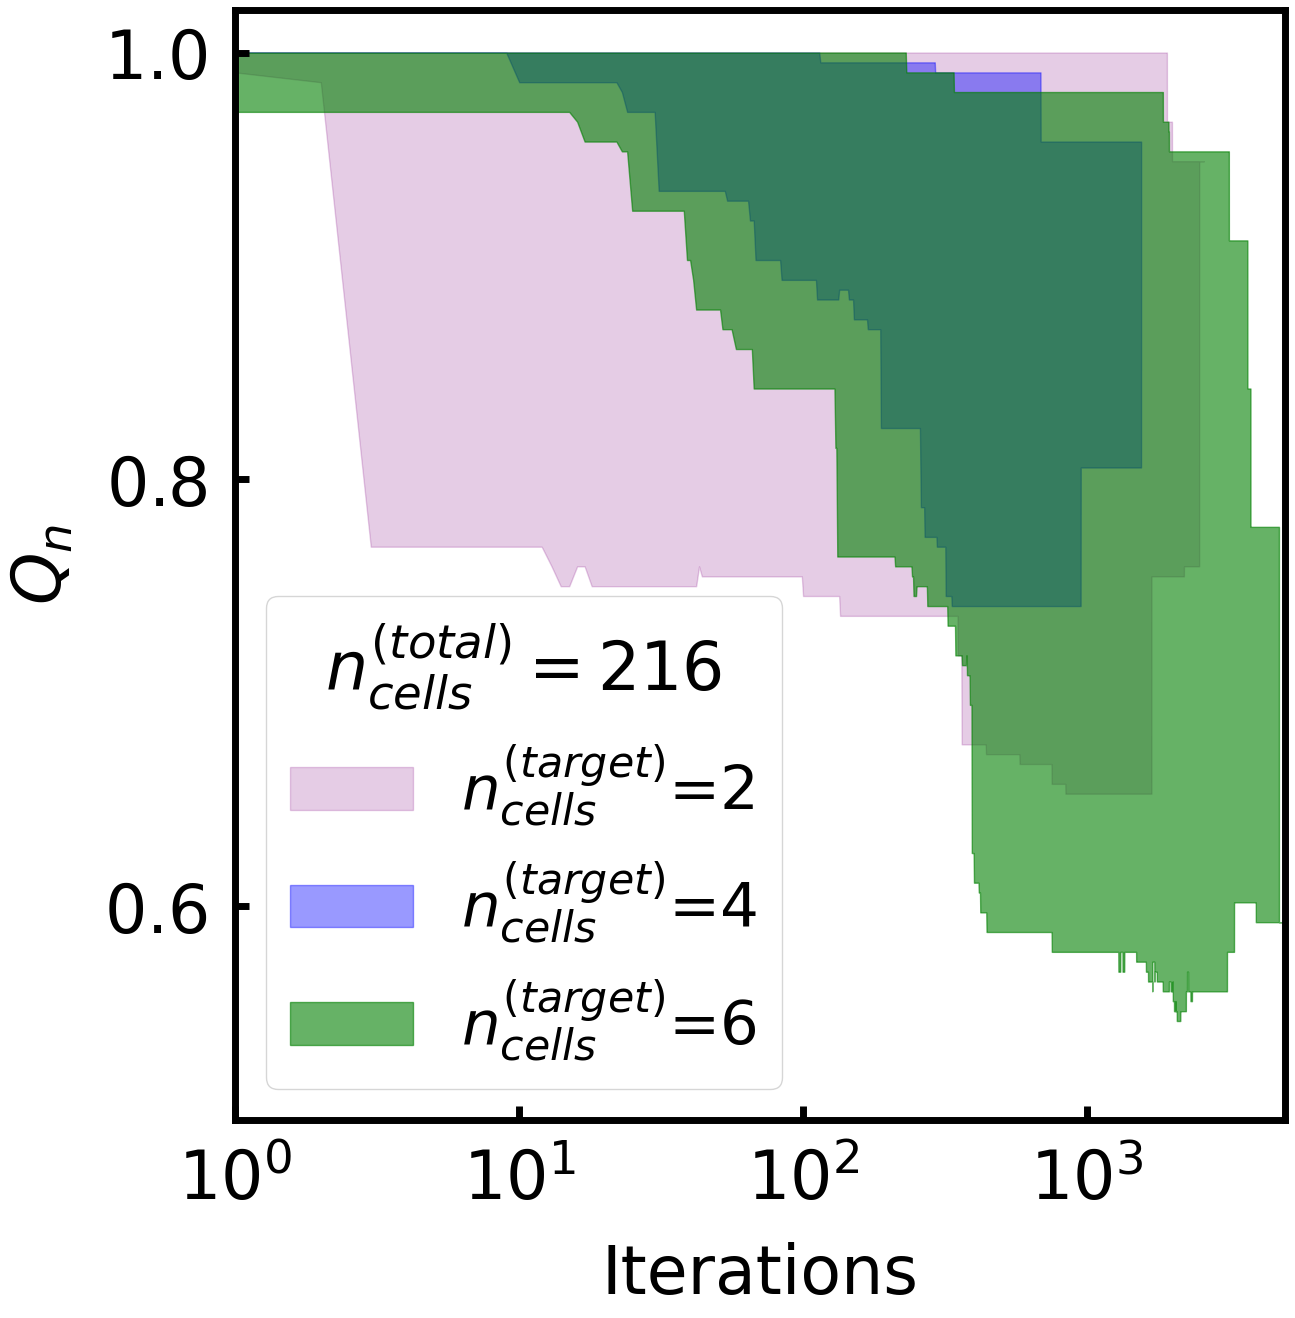

In [35]:
from toolbox import manuscriptPlots
import os
import numpy as np

graph_output = "graphs/overlaps_n_target_cells_l_6.jpg"
plotter = manuscriptPlots.plot()
plotter.set_ylim(0.5,1.02)
plotter.set_xlim(1,5000)
plotter.set_xticks([20*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel("Iterations")
plotter.set_ylabel(r"$Q_n$")

plotter.set_yScaled()
plotter.initialize_figure()
colors = {2:"purple",3:"red",4:"blue",5:"yellow",6:"green"}
alphas = {2:0.2,3:0.3,4:0.4,5:0.5,6:0.6}
for target in [2,4,6]:
    legend_added = False
    overlaps_dict = {}
    max_len = 0
    for i in range(100):
        dir = "data/{}_cells_mean_l_6/{:03d}/".format(target,i)
        if not os.path.isfile(dir+"errors.txt"):
            continue
        # errors = np.loadtxt(dir+"q_values.txt")
        errors = np.loadtxt(dir+"errors.txt")
        if errors[-1]>1e-4:
            continue
        overlaps = np.loadtxt(dir+"q_values.txt")
        overlaps_dict[i] = overlaps
        if len(overlaps)>max_len:
            max_len = len(overlaps)

    iter_to_overlaps = {i: [] for i in range(max_len)}
    for _, errors_array in overlaps_dict.items():
        for iter_idx in range(len(errors_array)):
            iter_to_overlaps[iter_idx].append(errors_array[iter_idx])
    # mean_errors = []
    # for iter_idx in range(max_len):
    #     mean_errors.append(np.mean(iter_to_overlaps[iter_idx]))
    # x_array = [i+1 for i in range(len(mean_errors))]
    # for i, errors in errors_dict.items():
    max_errors = []
    min_errors = []
    for iter_idx in range(max_len):
        if len(iter_to_overlaps[iter_idx])==0:
            break
        max_errors.append(np.max(iter_to_overlaps[iter_idx]))
        min_errors.append(np.min(iter_to_overlaps[iter_idx]))
    x_array = [i+1 for i in range(len(max_errors))]
    # plotter.plot_xy(x_array, mean_errors, color = colors[target], alpha = 0.4,label = "_none")
    # if legend_added:
    #     continue
    # plotter.plot_xy(x_array, mean_errors, color = colors[target], alpha = 0.4, label = r"$n_{cells}^{(target)}$"+"={}".format(target))
    legend_added = True
    plotter.plot_max_min_fill(x_array, max_errors, min_errors, color = colors[target], alpha = alphas[target], label = r"$n_{cells}^{(target)}$"+"={}".format(target))


# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
plotter.ax.legend(title = r"$n_{cells}^{(total)} = 216$",title_fontsize = 48,loc='lower left')
plotter.save_fig(graph_output)


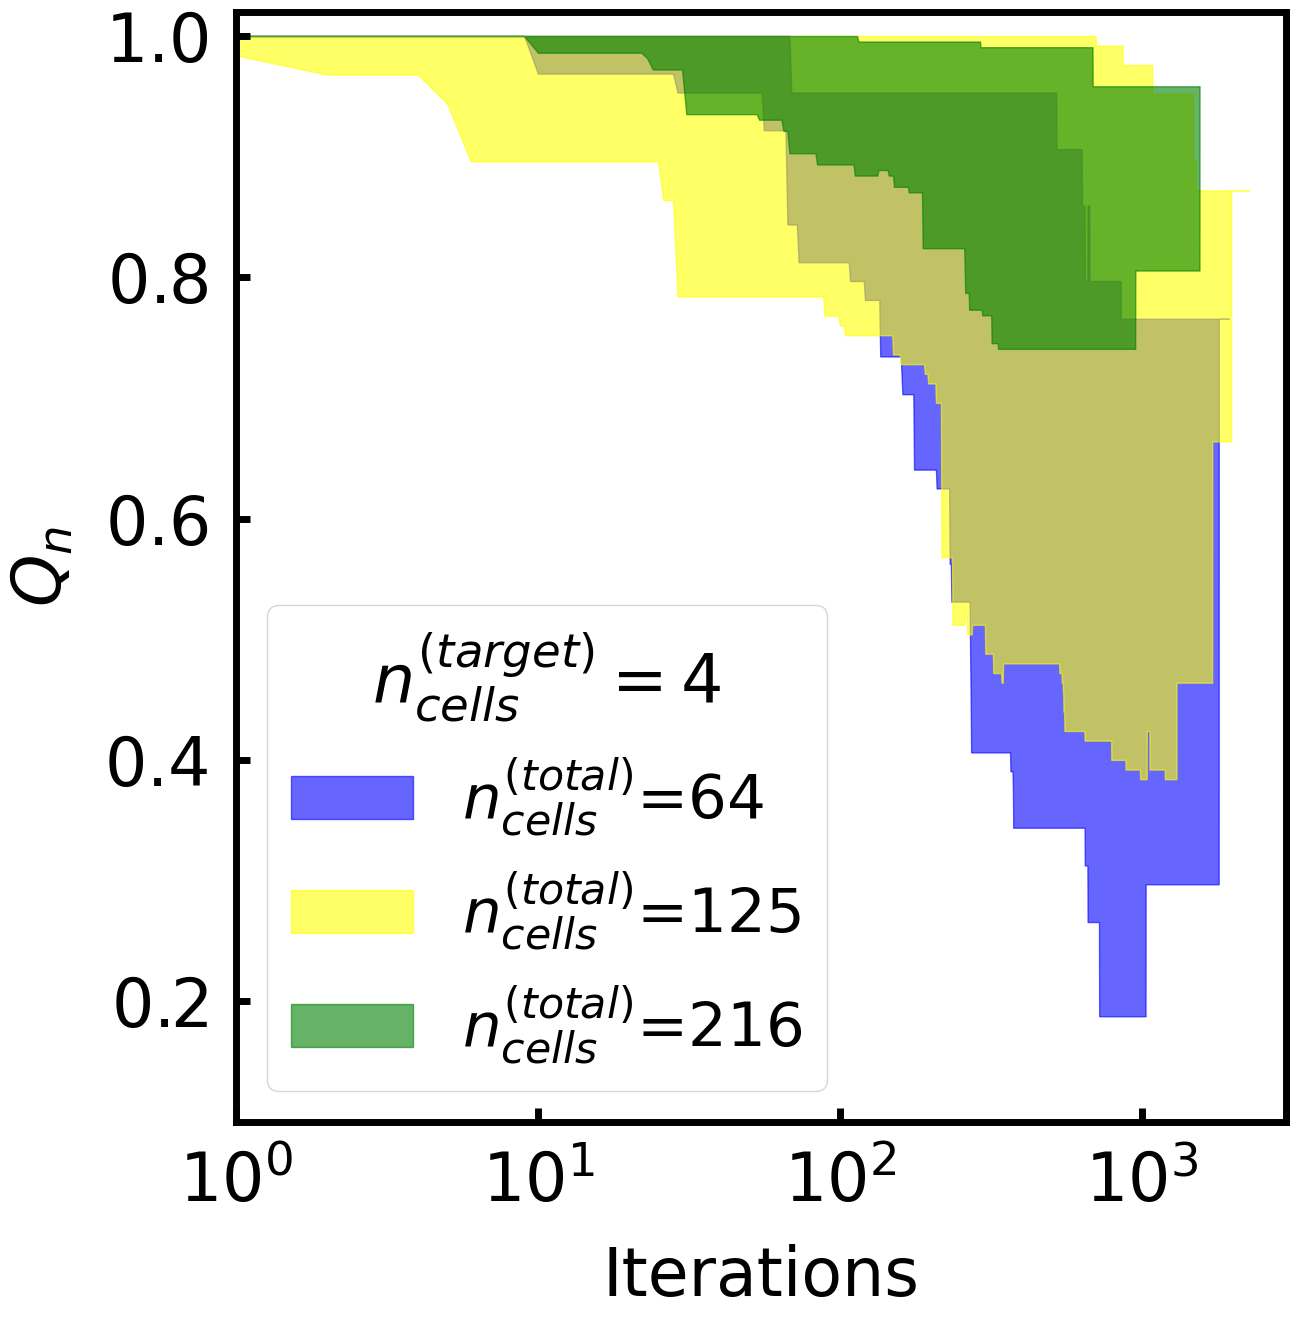

In [25]:
from toolbox import manuscriptPlots
import os
import numpy as np

graph_output = "graphs/overlaps_n_total_cells.jpg"
plotter = manuscriptPlots.plot()
plotter.set_ylim(0.1,1.02)
plotter.set_xlim(1,3000)
plotter.set_xticks([20*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel("Iterations")
plotter.set_ylabel(r"$Q_n$")

plotter.set_yScaled()
plotter.initialize_figure()
colors = {2:"purple",3:"red",4:"blue",5:"yellow",6:"green"}
alphas = {2:0.2,3:0.3,4:0.4,5:0.5,6:0.6}
for size in [4,5,6]:
    legend_added = False
    overlaps_dict = {}
    max_len = 0
    for i in range(100):
        dir = "data/4_cells_mean_l_{}/{:03d}/".format(size,i)
        if not os.path.isfile(dir+"errors.txt"):
            continue
        # errors = np.loadtxt(dir+"q_values.txt")
        errors = np.loadtxt(dir+"errors.txt")
        if errors[-1]>1e-4:
            continue
        overlaps = np.loadtxt(dir+"q_values.txt")
        overlaps_dict[i] = overlaps
        if len(overlaps)>max_len:
            max_len = len(overlaps)

    iter_to_overlaps = {i: [] for i in range(max_len)}
    for _, errors_array in overlaps_dict.items():
        for iter_idx in range(len(errors_array)):
            iter_to_overlaps[iter_idx].append(errors_array[iter_idx])
    # mean_errors = []
    # for iter_idx in range(max_len):
    #     mean_errors.append(np.mean(iter_to_overlaps[iter_idx]))
    # x_array = [i+1 for i in range(len(mean_errors))]
    # for i, errors in errors_dict.items():
    max_errors = []
    min_errors = []
    for iter_idx in range(max_len):
        if len(iter_to_overlaps[iter_idx])==0:
            break
        max_errors.append(np.max(iter_to_overlaps[iter_idx]))
        min_errors.append(np.min(iter_to_overlaps[iter_idx]))
    x_array = [i+1 for i in range(len(max_errors))]
    # plotter.plot_xy(x_array, mean_errors, color = colors[target], alpha = 0.4,label = "_none")
    # if legend_added:
    #     continue
    # plotter.plot_xy(x_array, mean_errors, color = colors[target], alpha = 0.4, label = r"$n_{cells}^{(target)}$"+"={}".format(target))
    legend_added = True
    plotter.plot_max_min_fill(x_array, max_errors, min_errors, color = colors[size], alpha = alphas[target], label = r"$n_{cells}^{(total)}$"+"={}".format(size**3))


# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
plotter.ax.legend(title = r"$n_{cells}^{(target)} = 4$",title_fontsize = 48,loc='lower left')
plotter.save_fig(graph_output)


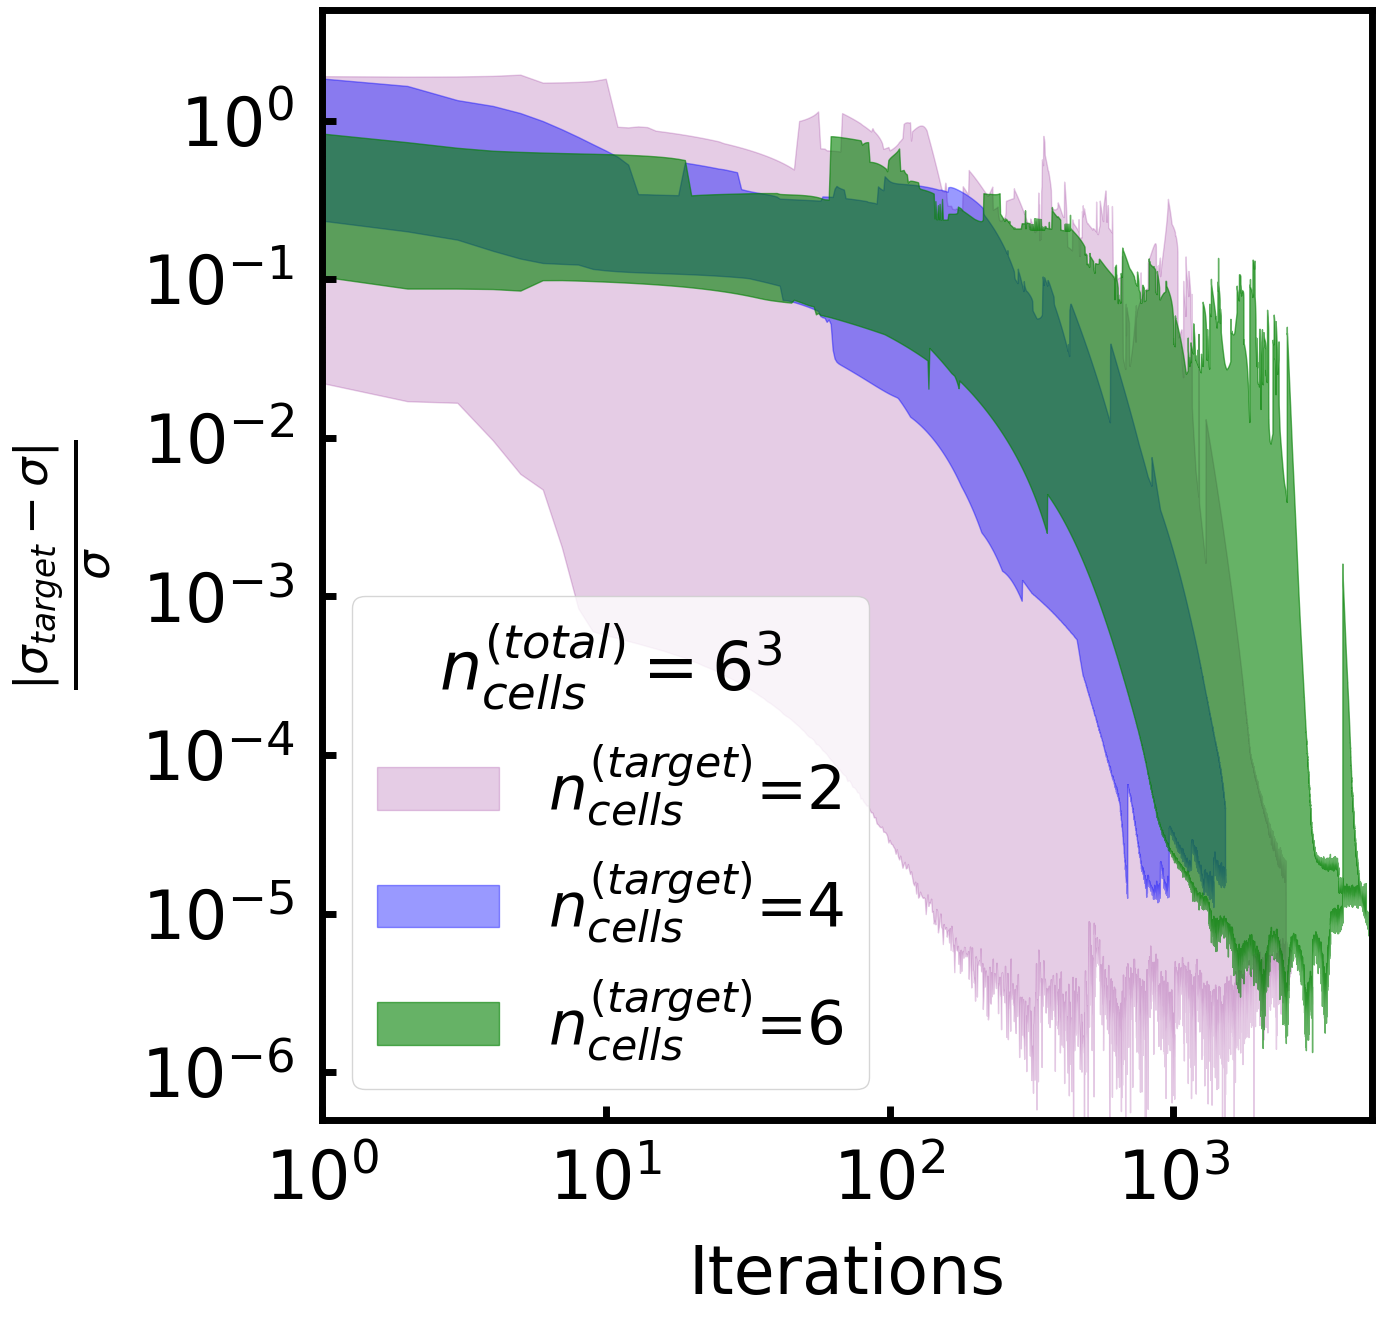

In [34]:
from toolbox import manuscriptPlots
import os
import numpy as np

graph_output = "graphs/errors_n_target_cells_l_6.jpg"
plotter = manuscriptPlots.plot()
plotter.set_ylim(5e-7,5)
plotter.set_xlim(1,5000)
plotter.set_xticks([20*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel("Iterations")
plotter.set_ylabel(r"$\frac{|\sigma_{target}-\sigma|}{\sigma}$")

plotter.set_yScaled()
plotter.initialize_figure()
colors = {2:"purple",3:"red",4:"blue",5:"yellow",6:"green"}
alphas = {2:0.2,3:0.3,4:0.4,5:0.5,6:0.6}
for target in [2,4,6]:
    legend_added = False
    errors_dict = {}
    max_len = 0
    for i in range(100):
        dir = "data/{}_cells_mean_l_6/{:03d}/".format(target,i)
        if not os.path.isfile(dir+"errors.txt"):
            continue
        # errors = np.loadtxt(dir+"q_values.txt")
        errors = np.loadtxt(dir+"errors.txt")
        if errors[-1]>1e-4:
            continue

        errors_dict[i] = errors
        if len(errors)>max_len:
            max_len = len(errors)

    iter_to_errors = {i: [] for i in range(max_len)}
    for _, errors_array in errors_dict.items():
        for iter_idx in range(len(errors_array)):
            iter_to_errors[iter_idx].append(errors_array[iter_idx])
    mean_errors = []
    for iter_idx in range(max_len):
        mean_errors.append(np.mean(iter_to_errors[iter_idx]))
    x_array = [i+1 for i in range(len(mean_errors))]
    errors = mean_errors
    # for i, errors in errors_dict.items():
    max_errors = []
    min_errors = []
    for iter_idx in range(max_len):
        max_errors.append(np.max(iter_to_errors[iter_idx]))
        min_errors.append(np.min(iter_to_errors[iter_idx]))
    # plotter.plot_xy(x_array, mean_errors, color = colors[target], alpha = 0.4,label = "_none")
    # if legend_added:
    #     continue
    # plotter.plot_xy(x_array, mean_errors, color = colors[target], alpha = 0.4, label = r"$n_{cells}^{(target)}$"+"={}".format(target))
    legend_added = True
    plotter.plot_max_min_fill(x_array, max_errors, min_errors, color = colors[target], alpha = alphas[target], label = r"$n_{cells}^{(target)}$"+"={}".format(target))


# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
plotter.ax.set_yscale("log")
plotter.ax.legend(title = r"$n_{cells}^{(total)} = 6^3$",title_fontsize = 48,loc='lower left')
plotter.save_fig(graph_output)


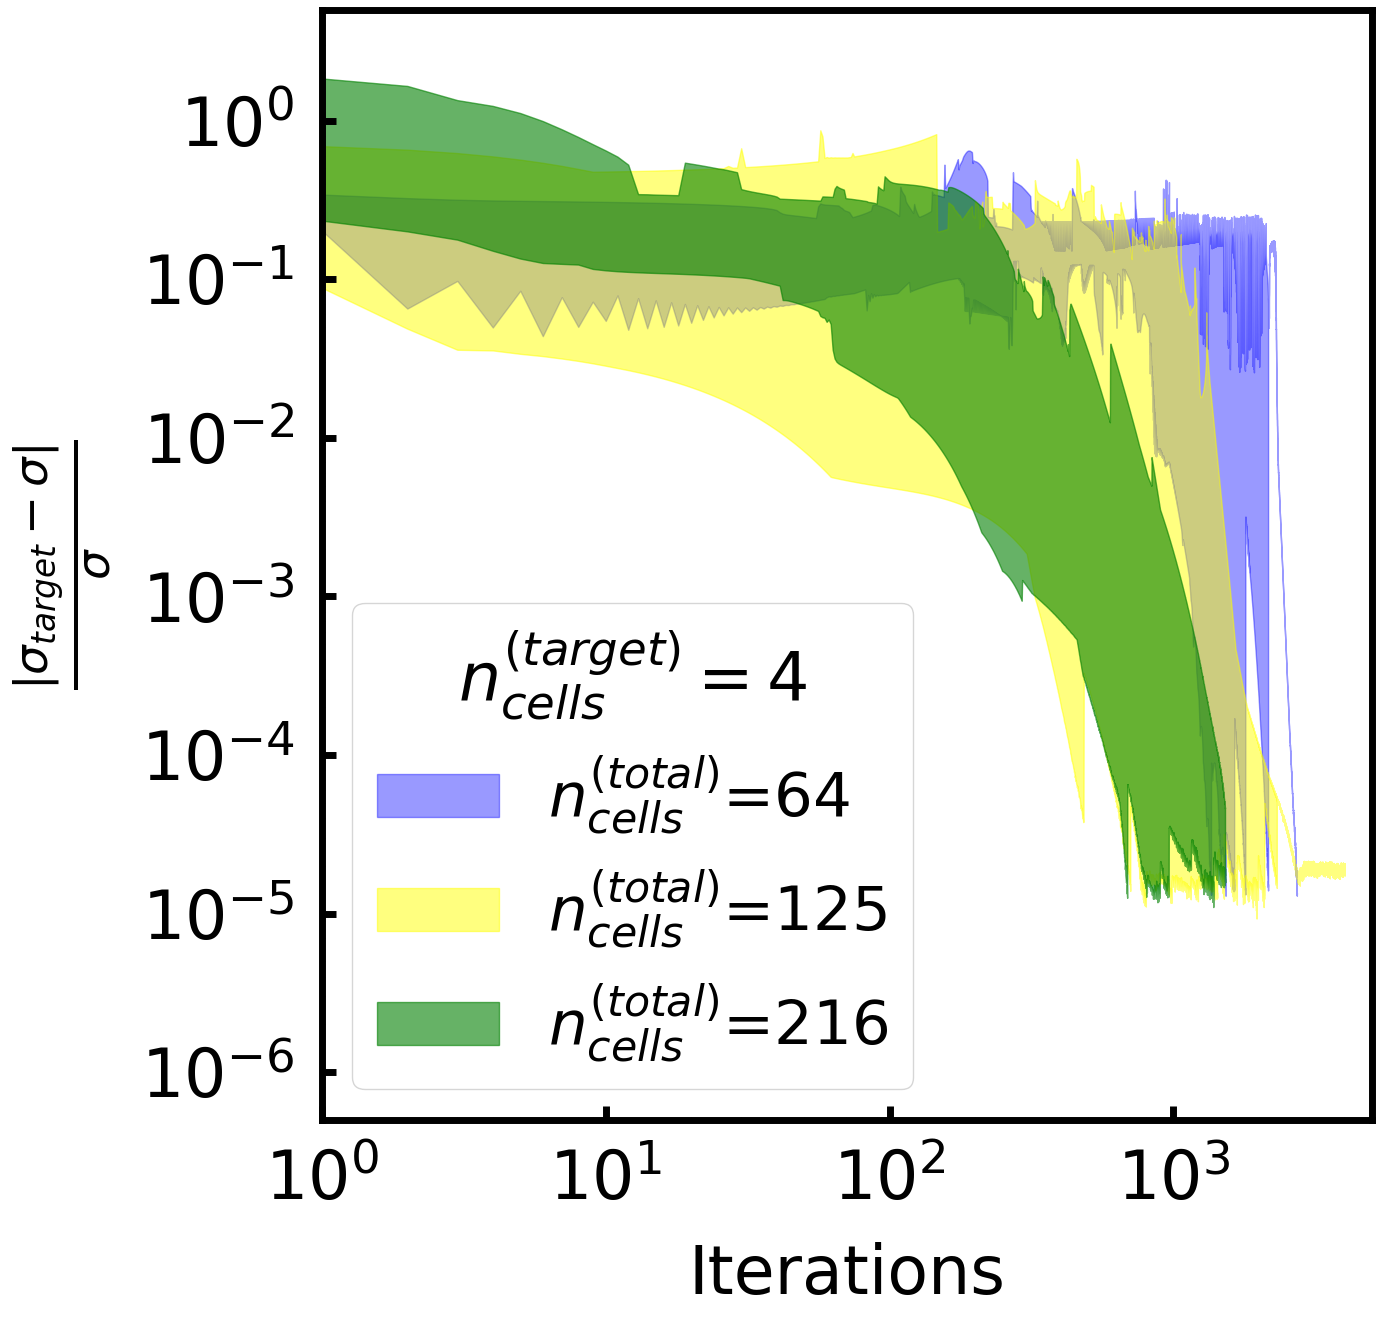

In [33]:
from toolbox import manuscriptPlots
import os
import numpy as np

graph_output = "graphs/errors_sys_size_4_target_cells.jpg"
plotter = manuscriptPlots.plot()
plotter.set_ylim(5e-7,5)
plotter.set_xlim(1,5000)
plotter.set_xticks([20*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel("Iterations")
plotter.set_ylabel(r"$\frac{|\sigma_{target}-\sigma|}{\sigma}$")

plotter.set_yScaled()
plotter.initialize_figure()
colors = {2:"purple",3:"red",4:"blue",5:"yellow",6:"green"}
alphas = {2:0.2,3:0.3,4:0.4,5:0.5,6:0.6}
for size in [4,5,6]:
    legend_added = False
    errors_dict = {}
    max_len = 0
    for i in range(100):
        dir = "data/4_cells_mean_l_{}/{:03d}/".format(size,i)
        if not os.path.isfile(dir+"errors.txt"):
            continue
        # errors = np.loadtxt(dir+"q_values.txt")
        errors = np.loadtxt(dir+"errors.txt")
        if errors[-1]>1e-4:
            continue

        errors_dict[i] = errors
        if len(errors)>max_len:
            max_len = len(errors)

    iter_to_errors = {i: [] for i in range(max_len)}
    for _, errors_array in errors_dict.items():
        for iter_idx in range(len(errors_array)):
            iter_to_errors[iter_idx].append(errors_array[iter_idx])
    mean_errors = []
    for iter_idx in range(max_len):
        mean_errors.append(np.mean(iter_to_errors[iter_idx]))
    x_array = [i+1 for i in range(len(mean_errors))]
    errors = mean_errors
    # for i, errors in errors_dict.items():
    max_errors = []
    min_errors = []
    for iter_idx in range(max_len):
        max_errors.append(np.max(iter_to_errors[iter_idx]))
        min_errors.append(np.min(iter_to_errors[iter_idx]))
    # plotter.plot_xy(x_array, mean_errors, color = colors[target], alpha = 0.4,label = "_none")
    # if legend_added:
    #     continue
    # plotter.plot_xy(x_array, mean_errors, color = colors[target], alpha = 0.4, label = r"$n_{cells}^{(target)}$"+"={}".format(target))
    legend_added = True
    plotter.plot_max_min_fill(x_array, max_errors, min_errors, color = colors[size], alpha = alphas[size], label = r"$n_{cells}^{(total)}$"+"={}".format(size**3))


# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
plotter.ax.set_yscale("log")
plotter.ax.legend(title = r"$n_{cells}^{(target)} = 4$",title_fontsize = 48,loc='lower left')
plotter.save_fig(graph_output)


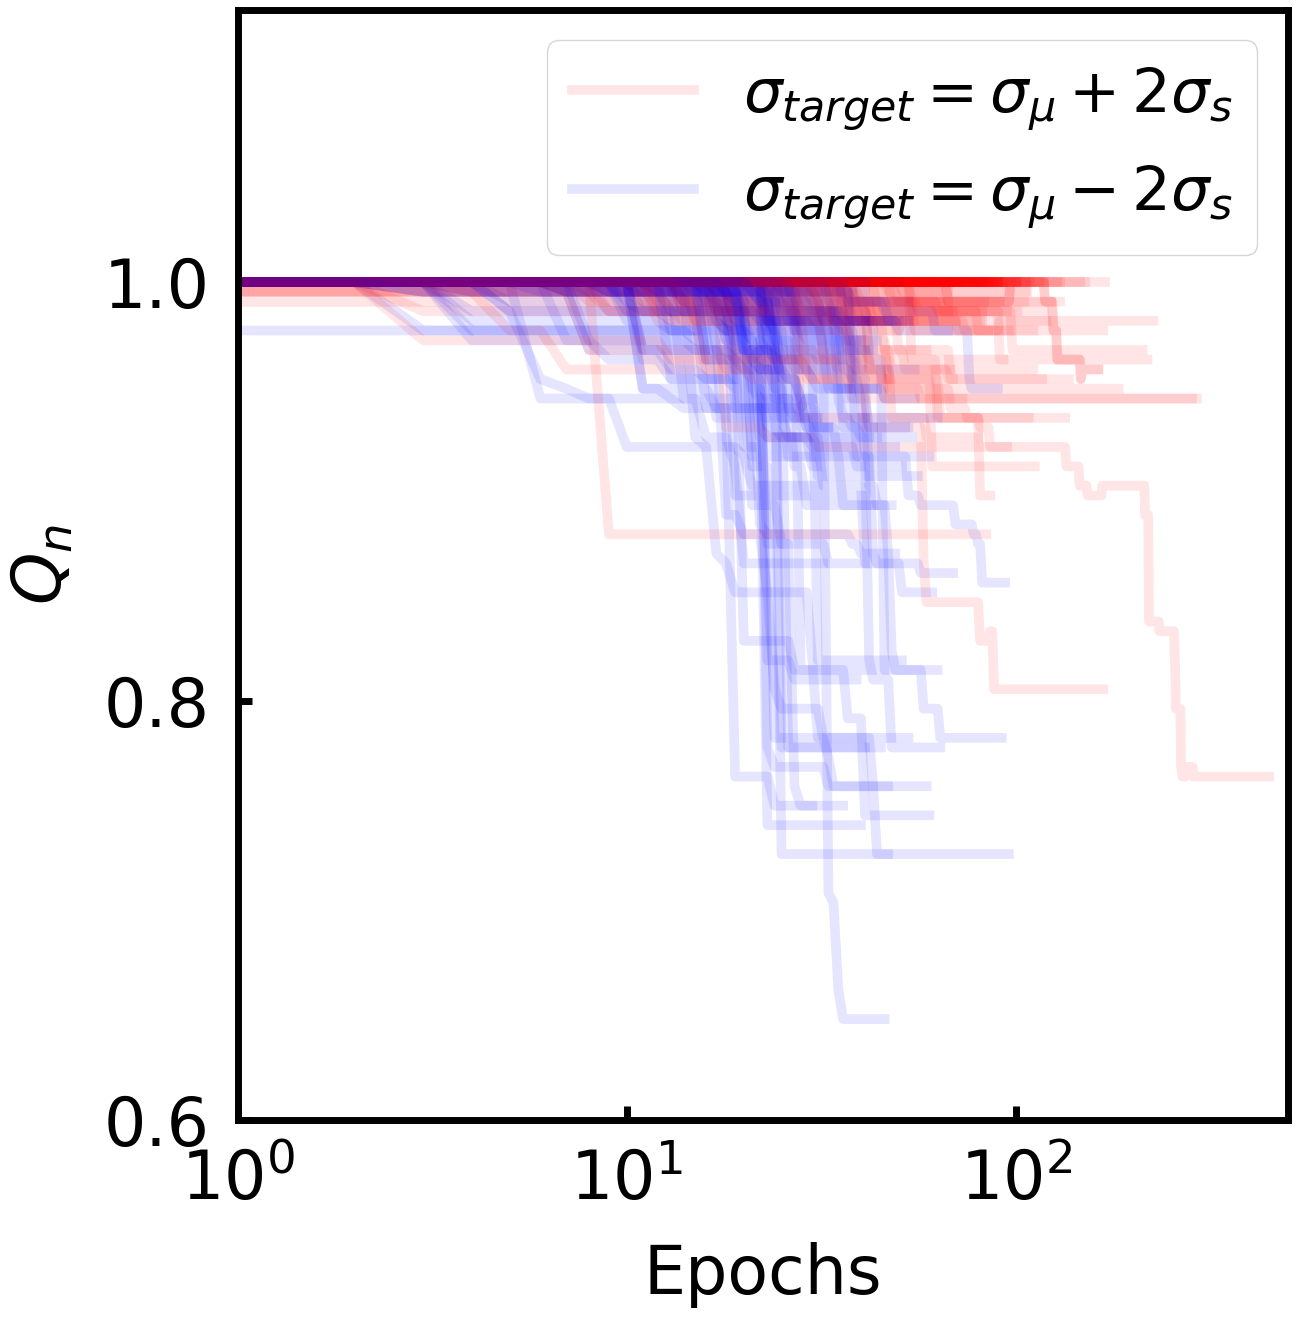

In [6]:
from toolbox import manuscriptPlots
import os
import numpy as np
plotter = manuscriptPlots.plot()
plotter.set_ylim(0.6,1.13)
plotter.set_xlim(1,500)
plotter.set_xticks([500*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel("Epochs")
plotter.set_ylabel(r"$Q_n$")
# plotter.set_yScaled()
plotter.initialize_figure()
for i in range(100):
    dir = "data/1_cell_increase_2_sigma/{:03d}/".format(i)
    if not os.path.isfile(dir+"errors.txt"):
        continue
    errors = np.loadtxt("{}errors.txt".format(dir))
    if errors[-1]>5e-6:
        continue
    q_values = np.loadtxt(dir+"q_values.txt")
    # print(dir, errors[-1])
    x_array = [i+1 for i in range(len(q_values))]
    plotter.plot_xy(x_array, q_values, color ="red", alpha = 0.1,label = "_none")
    if i==99:
        plotter.plot_xy(x_array, q_values, color ="red", alpha = 0.1, label = r"$\sigma_{target}=\sigma_\mu + 2\sigma_s$")
    dir = "data/1_cell_decrease_2_sigma/{:03d}/".format(i)
    if not os.path.isfile(dir+"errors.txt"):
        continue
    errors = np.loadtxt("{}errors.txt".format(dir))
    if errors[-1]>5e-6:
        continue
    q_values = np.loadtxt(dir+"q_values.txt")
    # print(dir, errors[-1])
    x_array = [i+1 for i in range(len(q_values))]
    plotter.plot_xy(x_array, q_values, color ="blue", alpha = 0.1,label = "_none")
    if i==99:
        plotter.plot_xy(x_array, q_values, color ="blue", alpha = 0.1, label = r"$\sigma_{target}=\sigma_\mu - 2\sigma_s$")


# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
plotter.ax.legend(loc='upper right')
plotter.save_fig("graphs/single_cell_overlaps.jpg")


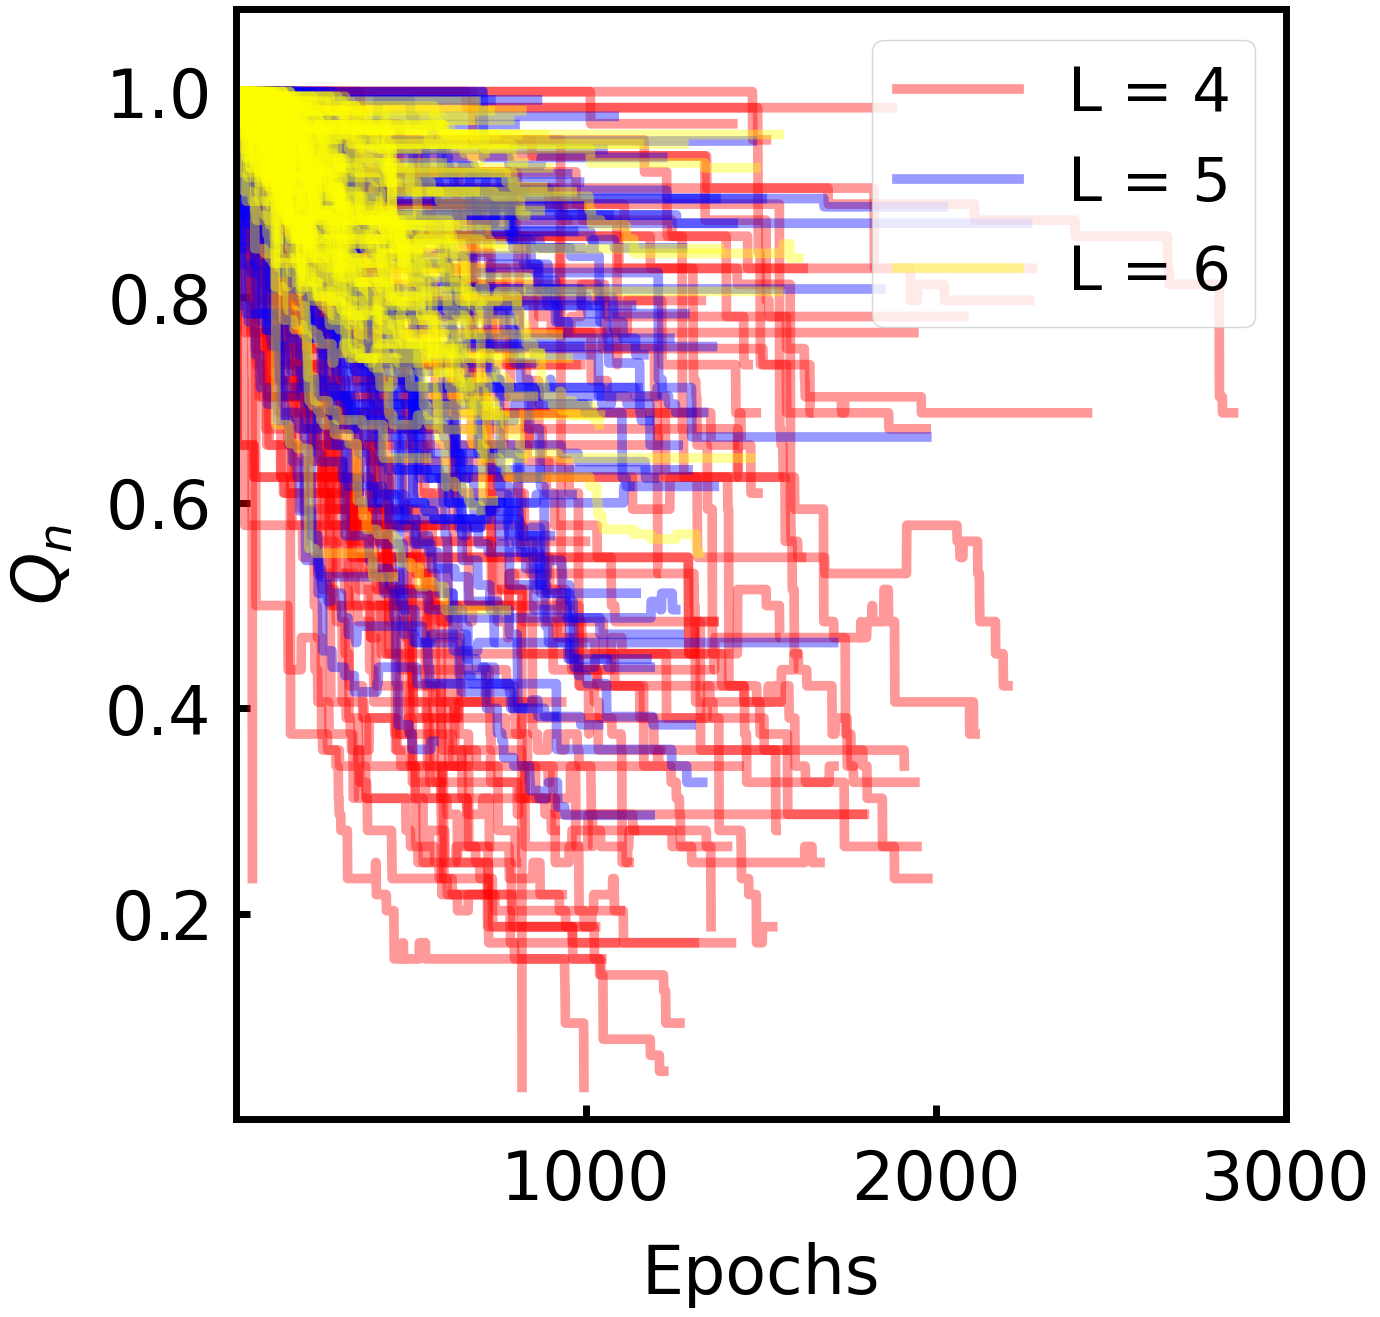

In [ ]:
from toolbox import manuscriptPlots
import os
import numpy as np
plotter = manuscriptPlots.plot()
plotter.set_ylim(0,1.08)
plotter.set_xlim(1,3000)
plotter.set_xticks([1000*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel("Epochs")
plotter.set_ylabel(r"$Q_n$")

plotter.initialize_figure()
# legend_added = False
# for i in range(100):
#     dir = "data/4_cells_mean/{:03d}/".format(i)
#     if not os.path.isfile(dir+"errors.txt"):
#         continue
#     q_values = np.loadtxt(dir+"q_values.txt")
#     # print(dir, errors[-1])
#     x_array = [i+1 for i in range(len(q_values))]
#     plotter.plot_xy(x_array, q_values, color ="black", alpha = 0.1,label = "_none")
    
#     if legend_added:
#         continue
#     plotter.plot_xy(x_array, q_values, color ="black", alpha = 0.1, label = r"$\sigma_{target}=\sigma_\mu$")
#     legend_added = True

colors = {4:"red",5:"blue",6:"yellow"}
for size in [4,5,6]:
    legend_added = False
    for i in range(100):
        dir = "data/4_cells_mean_l_{}/{:03d}/".format(size,i)
        if not os.path.isfile(dir+"q_values.txt"):
            continue
        with open(dir+"q_values.txt","r") as f:
            lines = f.readlines()
            if len(lines)<2:
                continue
        errors = np.loadtxt(dir+"q_values.txt")
        x_array = [i+1 for i in range(len(errors))]
        plotter.plot_xy(x_array, errors, color = colors[size], alpha = 0.4,label = "_none")
        if legend_added:
            continue
        plotter.plot_xy(x_array, errors, color = colors[size], alpha = 0.4, label = "L = {}".format(size))
        legend_added = True
# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
# plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
plotter.ax.legend(loc='upper right')
plotter.save_fig("graphs/4_cells_overlap_all_sizes.jpg")


/var/folders/0h/rds2j9093qd2m5lpv_zywsfh0000gn/T/ipykernel_95879/1508161807.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plotter.ax.legend(loc='upper right')


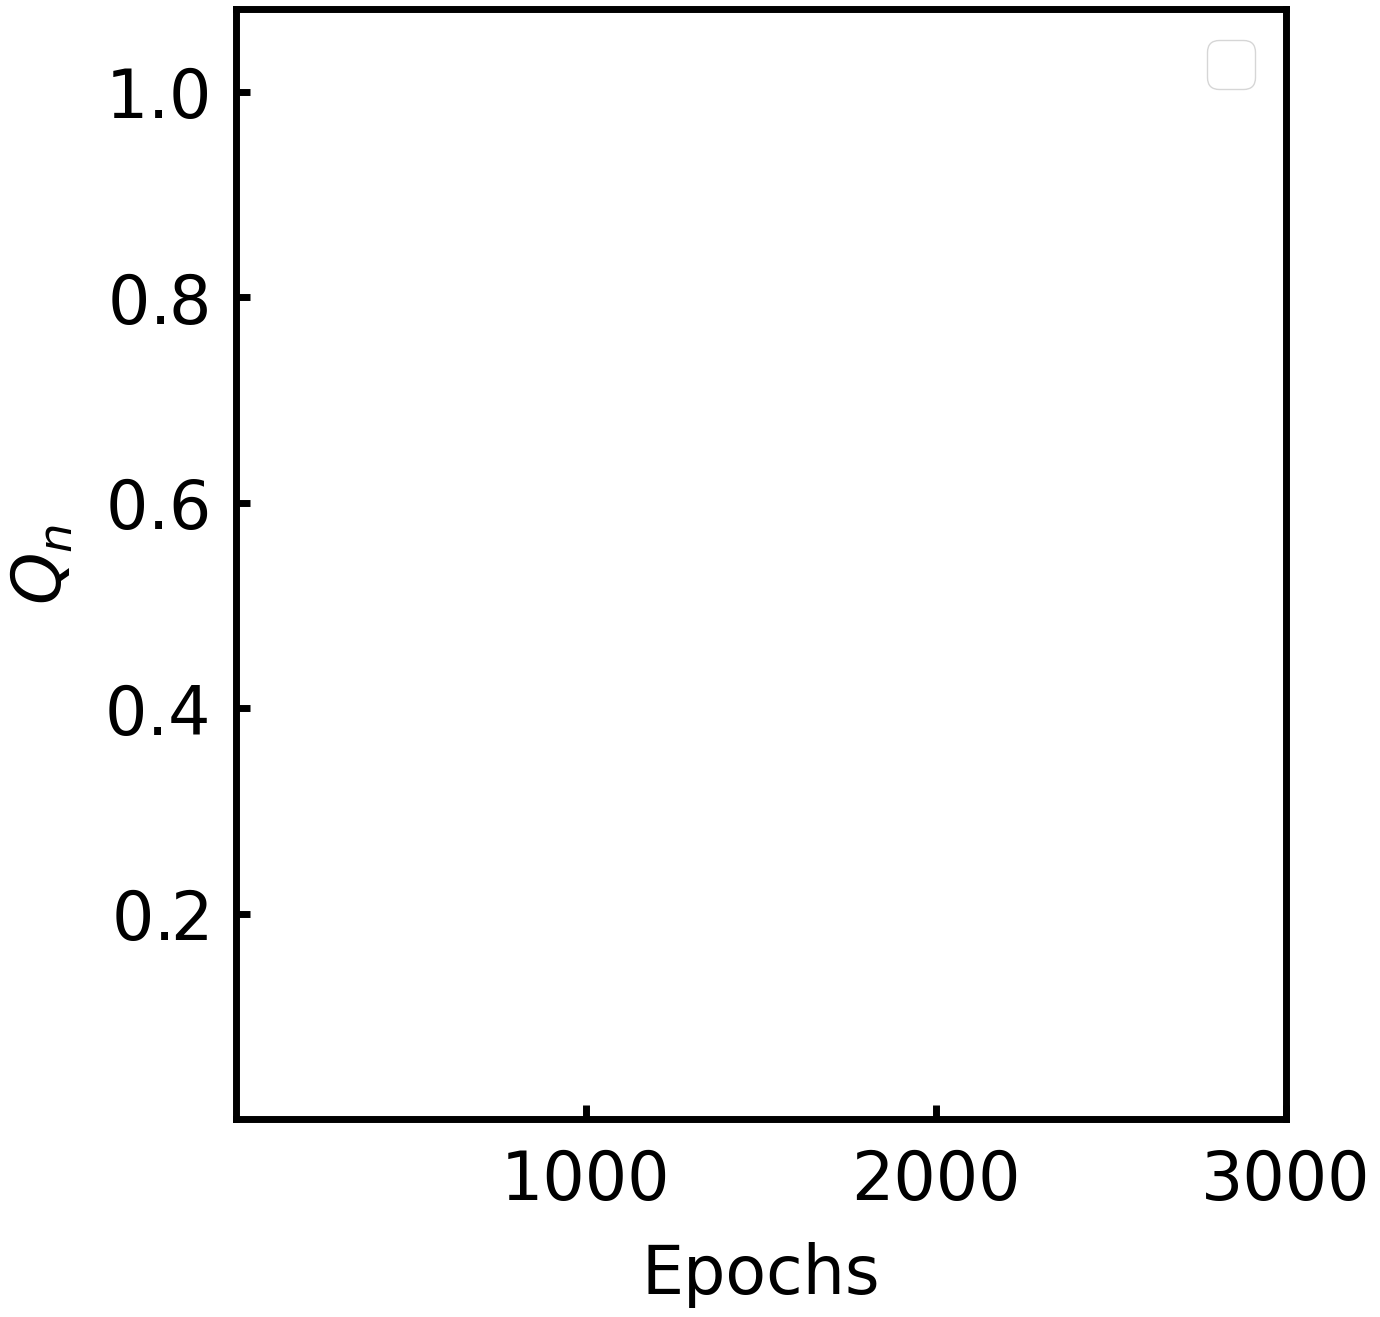

In [8]:
from toolbox import manuscriptPlots
import os
import numpy as np
plotter = manuscriptPlots.plot()
plotter.set_ylim(0,1.08)
plotter.set_xlim(1,3000)
plotter.set_xticks([1000*i for i in range(150)])
plotter.set_yticks([0.2*i for i in range(1,100)])
plotter.set_xlabel("Epochs")
plotter.set_ylabel(r"$Q_n$")

plotter.set_yScaled()
plotter.initialize_figure()
# legend_added = False
# for i in range(100):
#     dir = "data/4_cells_mean/{:03d}/".format(i)
#     if not os.path.isfile(dir+"errors.txt"):
#         continue
#     q_values = np.loadtxt(dir+"q_values.txt")
#     # print(dir, errors[-1])
#     x_array = [i+1 for i in range(len(q_values))]
#     plotter.plot_xy(x_array, q_values, color ="black", alpha = 0.1,label = "_none")
    
#     if legend_added:
#         continue
#     plotter.plot_xy(x_array, q_values, color ="black", alpha = 0.1, label = r"$\sigma_{target}=\sigma_\mu$")
#     legend_added = True

colors = {2:"red",3:"blue",4:"yellow",5:"yellow",6:"green"}
for n_cells in []:
    legend_added = False
    for i in range(100):
        dir = "data/{}_cells_mean_l_6/{:03d}/".format(n_cells,i)
        if not os.path.isfile(dir+"q_values.txt"):
            continue
        with open(dir+"q_values.txt","r") as f:
            lines = f.readlines()
            if len(lines)<2:
                continue
        errors = np.loadtxt(dir+"q_values.txt")
        x_array = [i+1 for i in range(len(errors))]
        plotter.plot_xy(x_array, errors, color = colors[n_cells], alpha = 0.4,label = "_none")
        if legend_added:
            continue
        plotter.plot_xy(x_array, errors, color = colors[n_cells], alpha = 0.4, label = "n = {}".format(n_cells))
        legend_added = True
# plotter.plot_errorfill(x_array,df_decrease["mean"].to_numpy(),df_decrease["sem"].to_numpy(),color = "black", alpha = 0.4, label = r"$\sigma_{hidden}^{(initial)}$")
# plotter.ax.set_xscale("log")
# plotter.ax.set_yscale("log")
plotter.ax.legend(loc='upper right')
plotter.save_fig("graphs/overlaps_all_sizes.jpg")
